# Sales Data Analysis and Business Insights

## Project Overview

This project analyzes retail sales data from a Superstore dataset to identify trends, profitability patterns, customer behavior, and business insights. The goal is to use data analysis techniques to support business decision-making and improve overall sales performance.# Sales Data Analysis and Business Insights

## Importance of the Analysis

Sales data analysis helps businesses:
- understand customer purchasing behavior
- identify profitable products and regions
- optimize pricing and discount strategies
- improve inventory management
- increase profitability through data-driven decisions

## Project Objectives

The objectives of this project are:
1. Perform data cleaning and preprocessing.
2. Analyze sales and profit trends.
3. Identify high-performing and loss-making products.
4. Visualize important business insights.
5. Provide recommendations based on the analysis.

## Tools and Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

## Dataset Information

Dataset: Sample Superstore Dataset from Kaggle

The dataset contains information related to:
- orders
- customers
- products
- sales
- profits
- discounts
- shipping details

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

## 2. Load the Dataset

In [ ]:
# Load dataset

df = pd.read_csv( r"C:\Users\Nandana\OneDrive\Desktop\sales_data_analysis_project\data\Sample - Superstore.csv",encoding='latin1')
print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

## 3. Dataset Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

## 4. Basic Dataset Exploration

In [ ]:
print("Dataset Shape:", df.shape)
print(df.columns)
df.describe()

Dataset Shape: (9994, 21)
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## 5. Data Cleaning

In [5]:
# Missing values
df.isnull().sum()

# Duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

# Convert date columns
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

Duplicate Rows: 0


## 6. Exploratory Data Analysis (EDA)

### Sales by Category

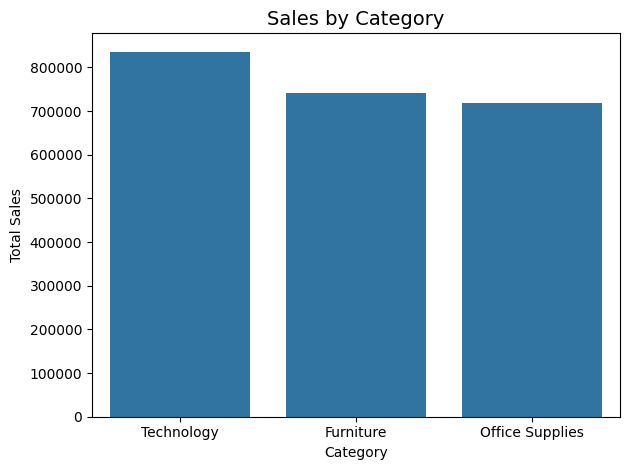

In [ ]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=category_sales.index, y=category_sales.values)
plt.title('Sales by Category', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

### Observation

- Technology category generated the highest sales.
- Office Supplies showed moderate sales performance.
- Furniture category contributed comparatively lower sales.

### Profit by Region

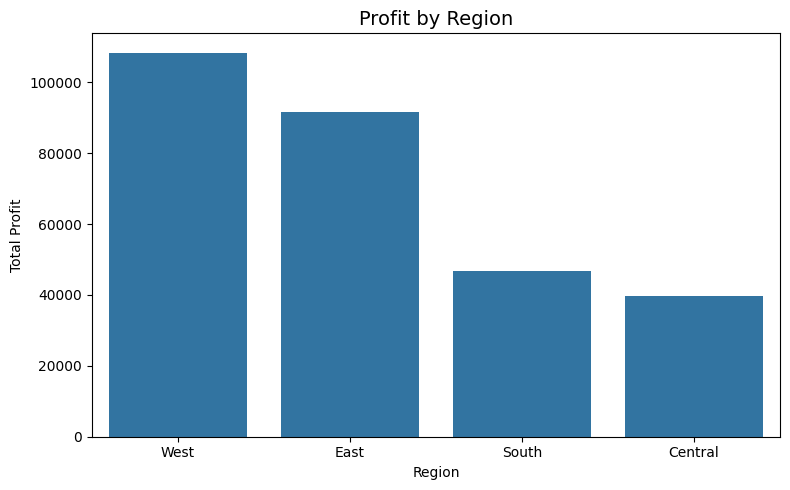

In [ ]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=region_profit.index, y=region_profit.values)
plt.title('Profit by Region', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Total Profit')
plt.tight_layout()
plt.show()

### Observation

- West region generated the highest overall profit.
- Central region showed comparatively lower profitability.

### Monthly Sales Trend

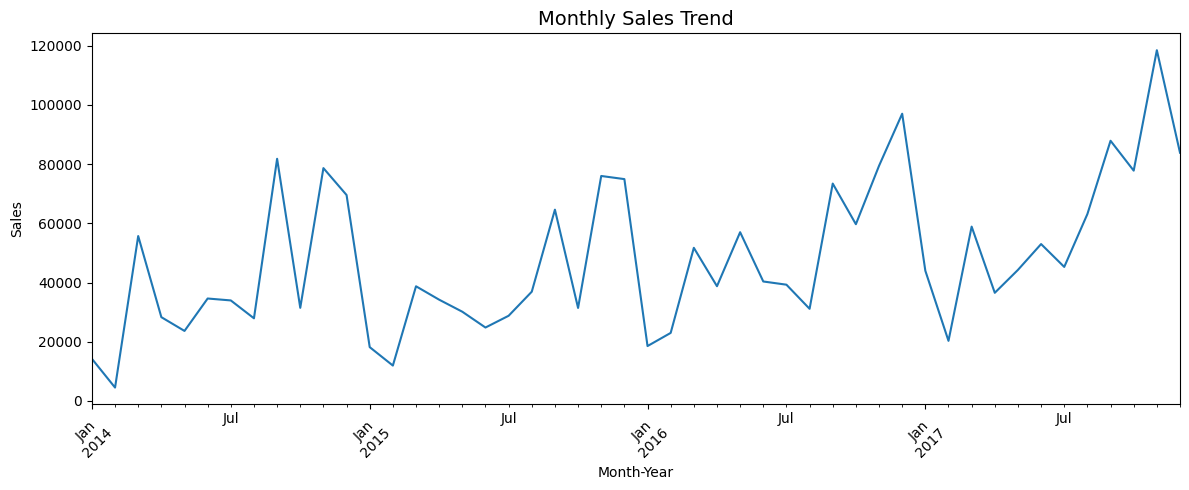

In [ ]:
df['Month_Year'] = df['Order Date'].dt.to_period('M')

monthly_sales = df.groupby('Month_Year')['Sales'].sum()
plt.figure(figsize=(12,5))
monthly_sales.plot()
plt.title('Monthly Sales Trend', fontsize=14)
plt.xlabel('Month-Year')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

- Sales fluctuated across different months.
- Certain periods showed noticeable spikes in demand.

### Top 10 Sub-Categories by Sales

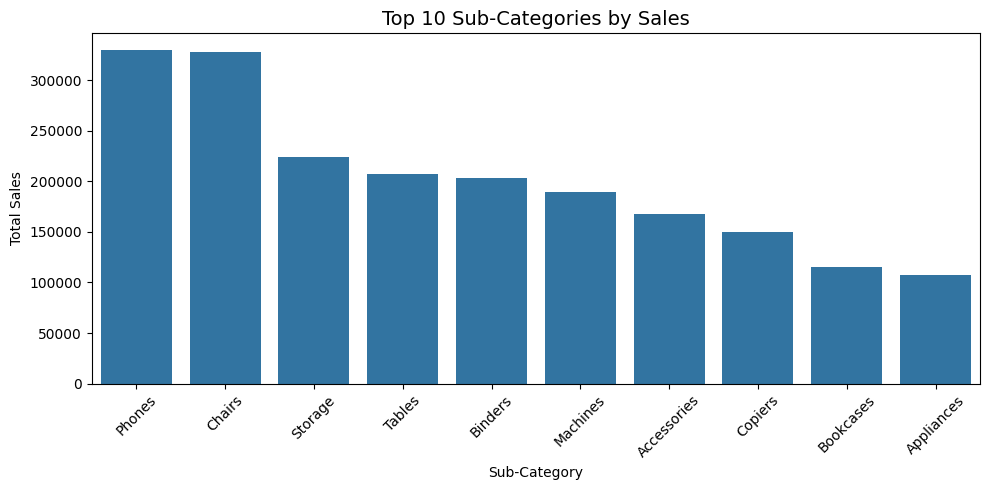

In [ ]:
top_products = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_products.index, y=top_products.values)
plt.title('Top 10 Sub-Categories by Sales', fontsize=14)
plt.xlabel('Sub-Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

- Phones and Chairs generated the highest sales among all sub-categories.
- Technology-related products showed strong demand.

### Correlation Heatmap

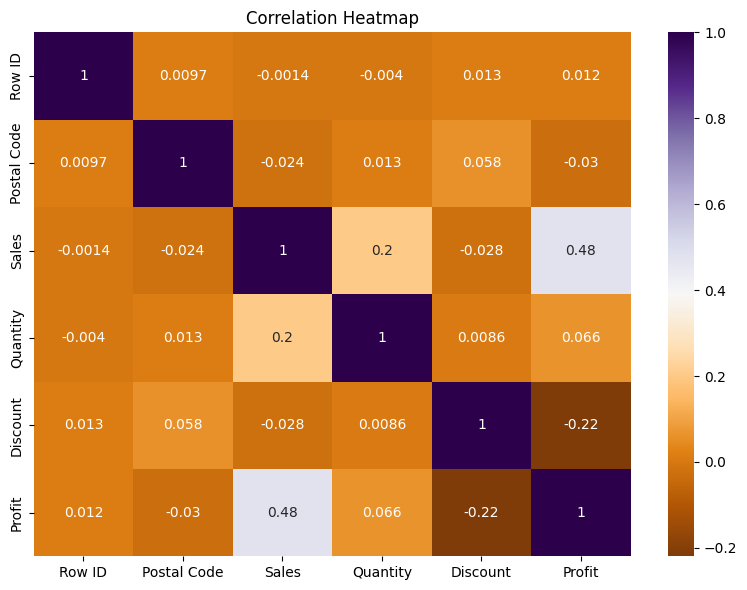

In [ ]:
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='PuOr')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### Observation

- Sales and Profit showed moderate positive correlation.
- Discounts negatively impacted profitability in several cases.

## 7. Advanced Analysis

### Discount vs Profit Analysis

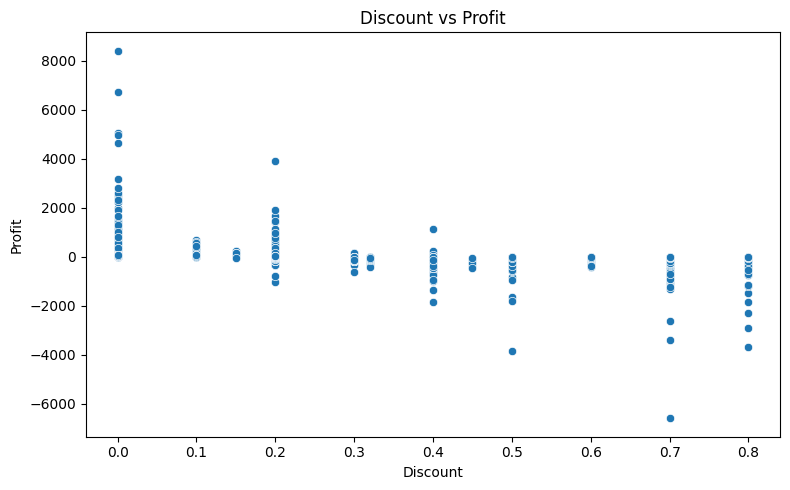

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Discount', y='Profit', data=df)
plt.title('Discount vs Profit')
plt.tight_layout()
plt.show()

### Observation

- Higher discounts often resulted in lower profits.
- Several highly discounted transactions generated losses.

### Loss-Making Products

In [ ]:
loss_products = df[df['Profit'] < 0]
loss_products.groupby('Sub-Category')['Profit'].sum().sort_values()

Sub-Category
Binders       -38510.4964
Tables        -32412.1483
Machines      -30118.6682
Bookcases     -12152.2060
Chairs         -9880.8413
Appliances     -8629.6412
Phones         -7530.6235
Furnishings    -6490.9134
Storage        -6426.3038
Supplies       -3015.6219
Accessories     -930.6265
Fasteners        -33.1952
Name: Profit, dtype: float64

### Most Profitable customers

In [ ]:
top_customers = df.groupby('Customer Name')['Profit'].sum().sort_values(ascending=False).head(10)
print(top_customers)

Customer Name
Tamara Chand            8981.3239
Raymond Buch            6976.0959
Sanjit Chand            5757.4119
Hunter Lopez            5622.4292
Adrian Barton           5444.8055
Tom Ashbrook            4703.7883
Christopher Martinez    3899.8904
Keith Dawkins           3038.6254
Andy Reiter             2884.6208
Daniel Raglin           2869.0760
Name: Profit, dtype: float64


### Segment wise sales

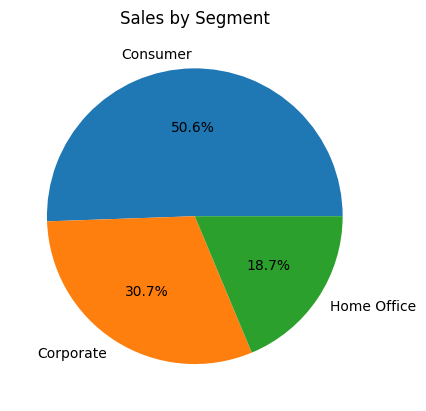

<Figure size 640x480 with 0 Axes>

In [15]:
segment_sales = df.groupby('Segment')['Sales'].sum()
segment_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title('Sales by Segment')
plt.ylabel('')
plt.show()
plt.tight_layout()

### Observation

- Consumer segment contributed the highest sales.
- Home Office segment showed comparatively lower contribution.

## 8. Final Business Insights

### Key Insights

1. Technology category generated the highest sales.
2. West region contributed maximum profit.
3. Discounts negatively affected profitability.
4. Consumer segment dominated overall sales.
5. Some sub-categories consistently generated losses.

## 9. Business Recommendations

### Recommendations

- Reduce excessive discounting on low-profit products.
- Focus marketing efforts on Technology products.
- Improve profitability strategies in low-performing regions.
- Analyze seasonal demand for better inventory planning.
- Build customer retention strategies for high-value customers.

## 10. Conclusion

This project analyzed retail sales data to identify trends, profitability patterns, customer behavior, and business insights. The analysis highlighted key opportunities for improving profitability and optimizing sales strategies using data-driven decision-making.